# Mean ocean surface circulation in Beaufort

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [11]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:36751")
client

<Client: 'tcp://127.0.0.1:36751' processes=8 threads=32, memory=123.95 GiB>

In [12]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [13]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [14]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [15]:
# open UVEL zarr store - Horizontal velocity in the model +x direction
UVEL_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/UVEL_AVG_DAILY.ZARR/', s3_options)

# open VVEL zarr store - Horizontal velocity in the model +y direction
VVEL_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/VVEL_AVG_DAILY.ZARR/', s3_options)

In [69]:
# Select beaufort sea region
uvel_beaufort = UVEL_da.UVEL.rename({'i_g':'i'}).isel(k=0,i=slice(450,750),j=slice(110,390))
vvel_beaufort = VVEL_da.VVEL.rename({'j_g':'j'}).isel(k=0,i=slice(450,750),j=slice(110,390))

In [60]:
# Select beaufort sea region that goes farther west to look at large vectors
uvel_beaufort = UVEL_da.UVEL.rename({'i_g':'i'}).isel(k=0,i=slice(450,750),j=slice(110,450))
vvel_beaufort = VVEL_da.VVEL.rename({'j_g':'j'}).isel(k=0,i=slice(450,750),j=slice(110,450))

### Rotate the dataset so Alaska is on the bottom

In [20]:
def rotate_dataarray_90ccw(da):
    """
    Rotate a 3D xarray.DataArray (time, i, j) 90 degrees counterclockwise.
    
    Parameters:
        da (xr.DataArray): Input data array with dims ('time', 'i', 'j').
        
    Returns:
        xr.DataArray: Rotated DataArray with dims ('time', 'i', 'j').
    """
    rotated = np.rot90(da,3,axes=[1,2])
    
    out = xr.DataArray(
        data=rotated,
        dims=('time','i','j'),
        coords={
            'time': da['time'],
            'i': da['i'],
            'j': da['j']
        },
        name=f"{da.name}"
    )
    
    return out

In [78]:
# Rotate the fields so that alaska is on the bottom
uvel_beaufort_rot = rotate_dataarray_90ccw(uvel_beaufort)
vvel_beaufort_rot = rotate_dataarray_90ccw(vvel_beaufort)

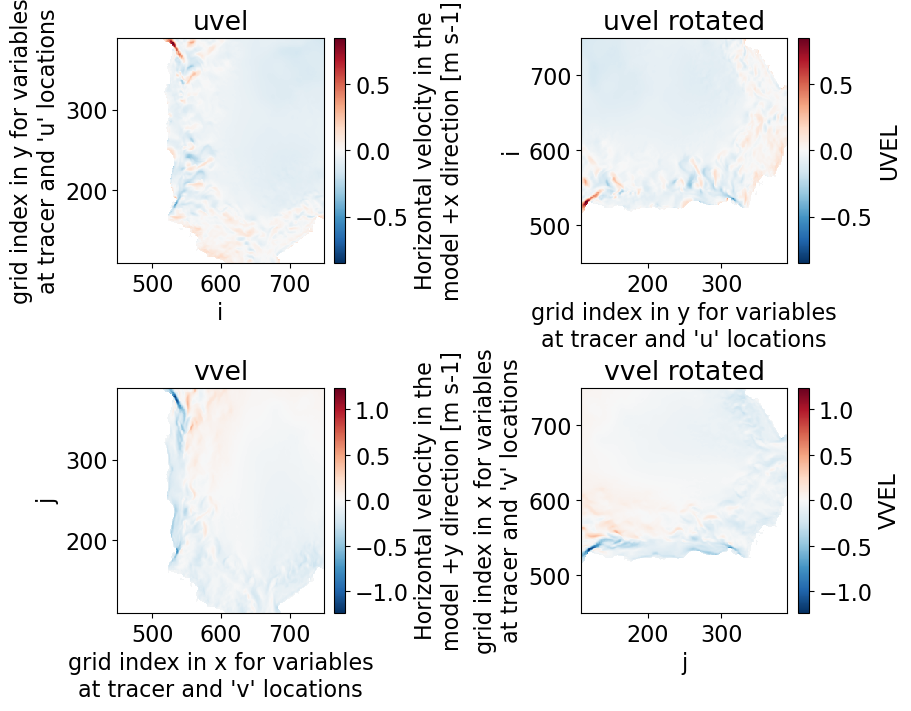

In [93]:
# Double check rotation
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=[9,7],layout='constrained')
uvel_beaufort.isel(time=200).plot(ax=ax1);
uvel_beaufort_rot.isel(time=200).plot(ax=ax2);
vvel_beaufort.isel(time=200).plot(ax=ax3);
vvel_beaufort_rot.isel(time=200).plot(ax=ax4);
ax1.set_title("uvel")
ax2.set_title("uvel rotated")
ax3.set_title("vvel")
ax4.set_title("vvel rotated");

In [94]:
# Group by month and compute climatological monthly means
uvel_monthly_mean_rot = uvel_beaufort_rot.groupby('time.month').mean('time')
vvel_monthly_mean_rot = vvel_beaufort_rot.groupby('time.month').mean('time')

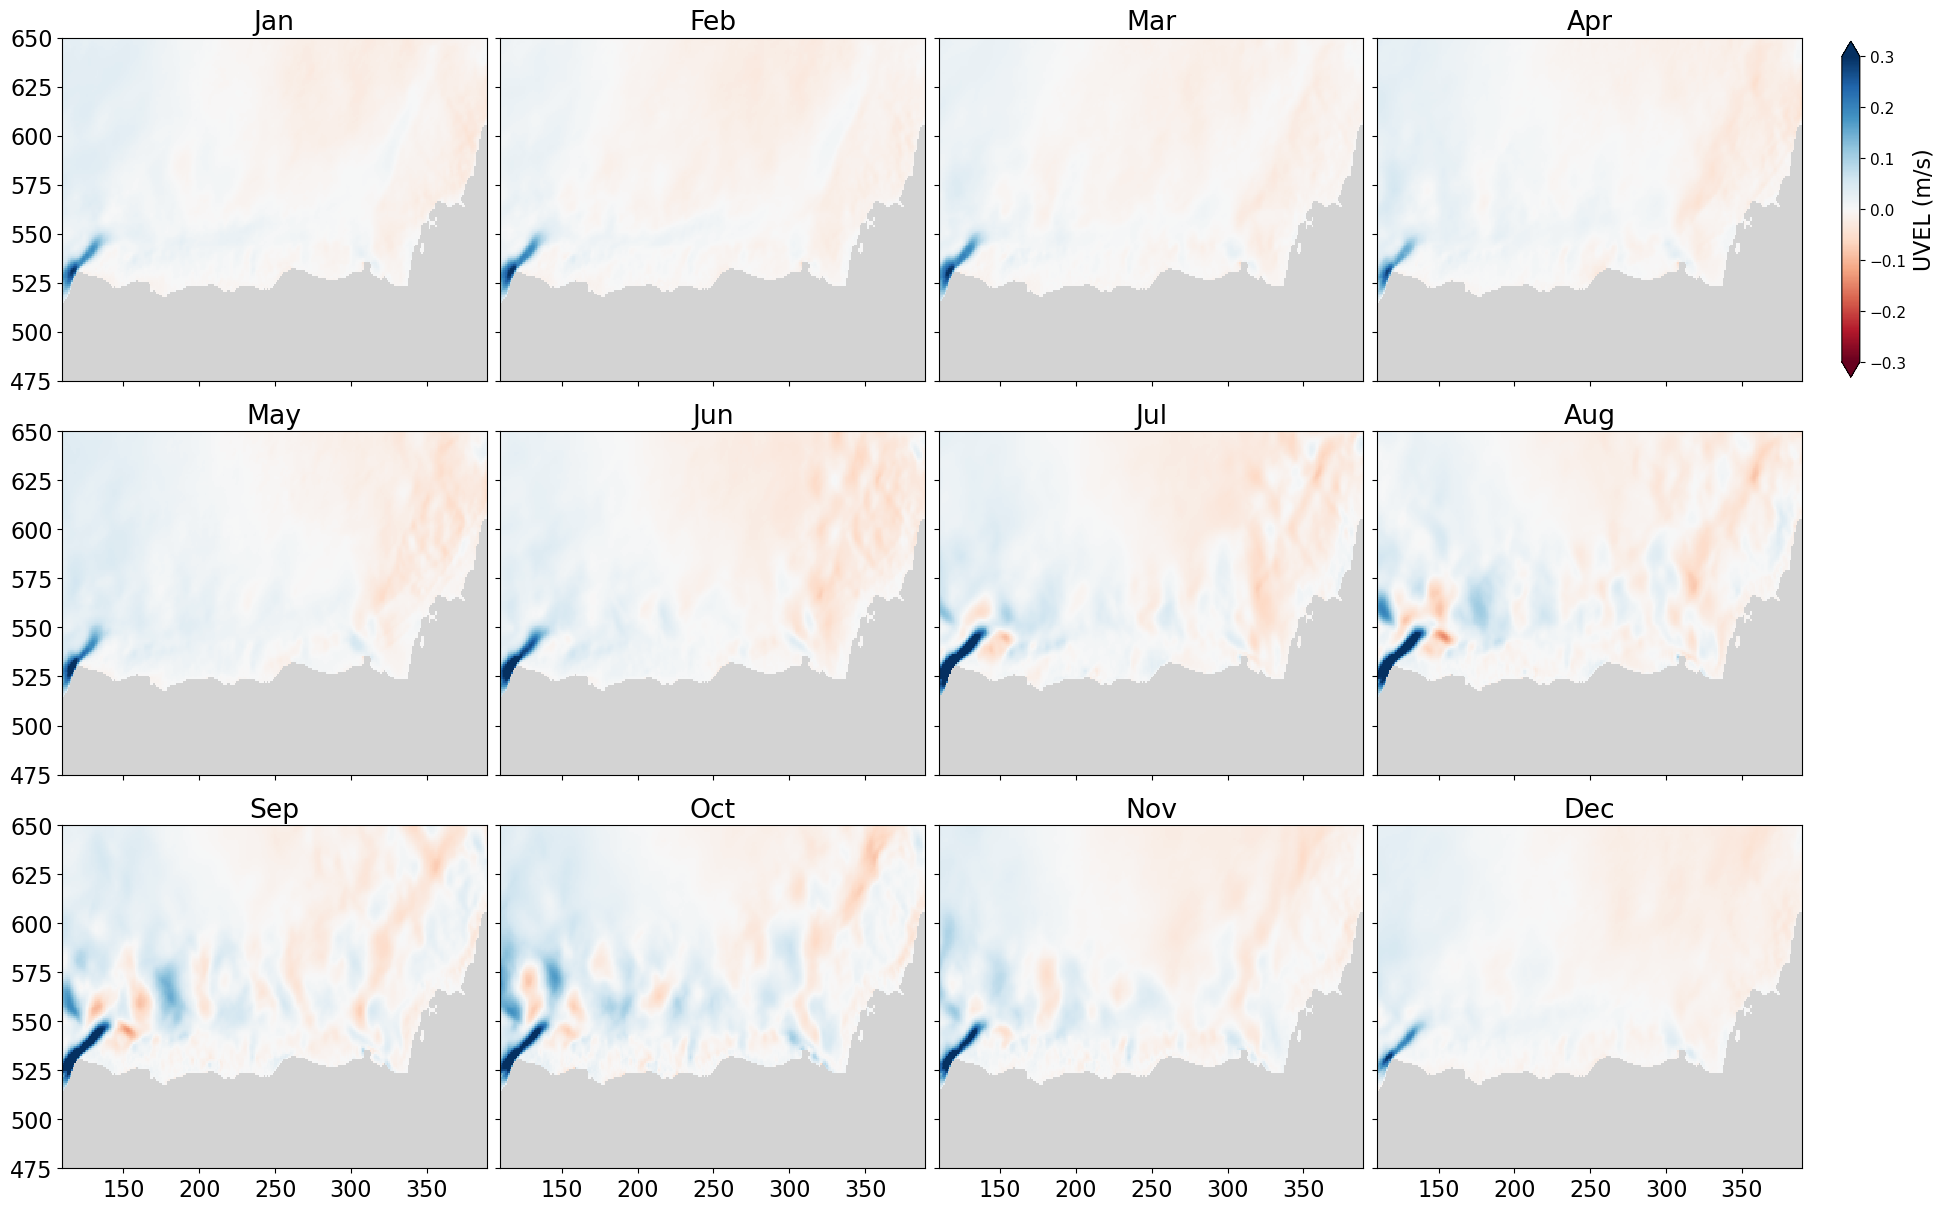

In [95]:
plt.rcParams["font.size"] = 16
fig, axs = plt.subplots(3, 4, figsize=(18, 12), sharex=True, sharey=True, layout='constrained')
axs = axs.ravel()

for i in range(12):
    ax = axs[i]

    # Make background gray
    ax.set_facecolor('lightgray')
    
    # Plot uvel_monthly_mean
    cbar_plot = uvel_monthly_mean_rot.isel(month=i).plot(ax=ax,vmin=-0.3,vmax=0.3,cmap='RdBu',add_colorbar=False,extend='both')

    # ax.set_title(f"Month {i+1}", fontsize=16)
    ax.set_title(f"{['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][i]}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    ax.set_ylim(475,650)

# Add a single colorbar for SSS
cbar_ax = fig.add_axes([1.02, 0.69, 0.01, 0.28])  # left, bottom, width, height
cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical',extend='both')
cbar.set_label("UVEL (m/s)")
cbar.ax.tick_params(labelsize=11)

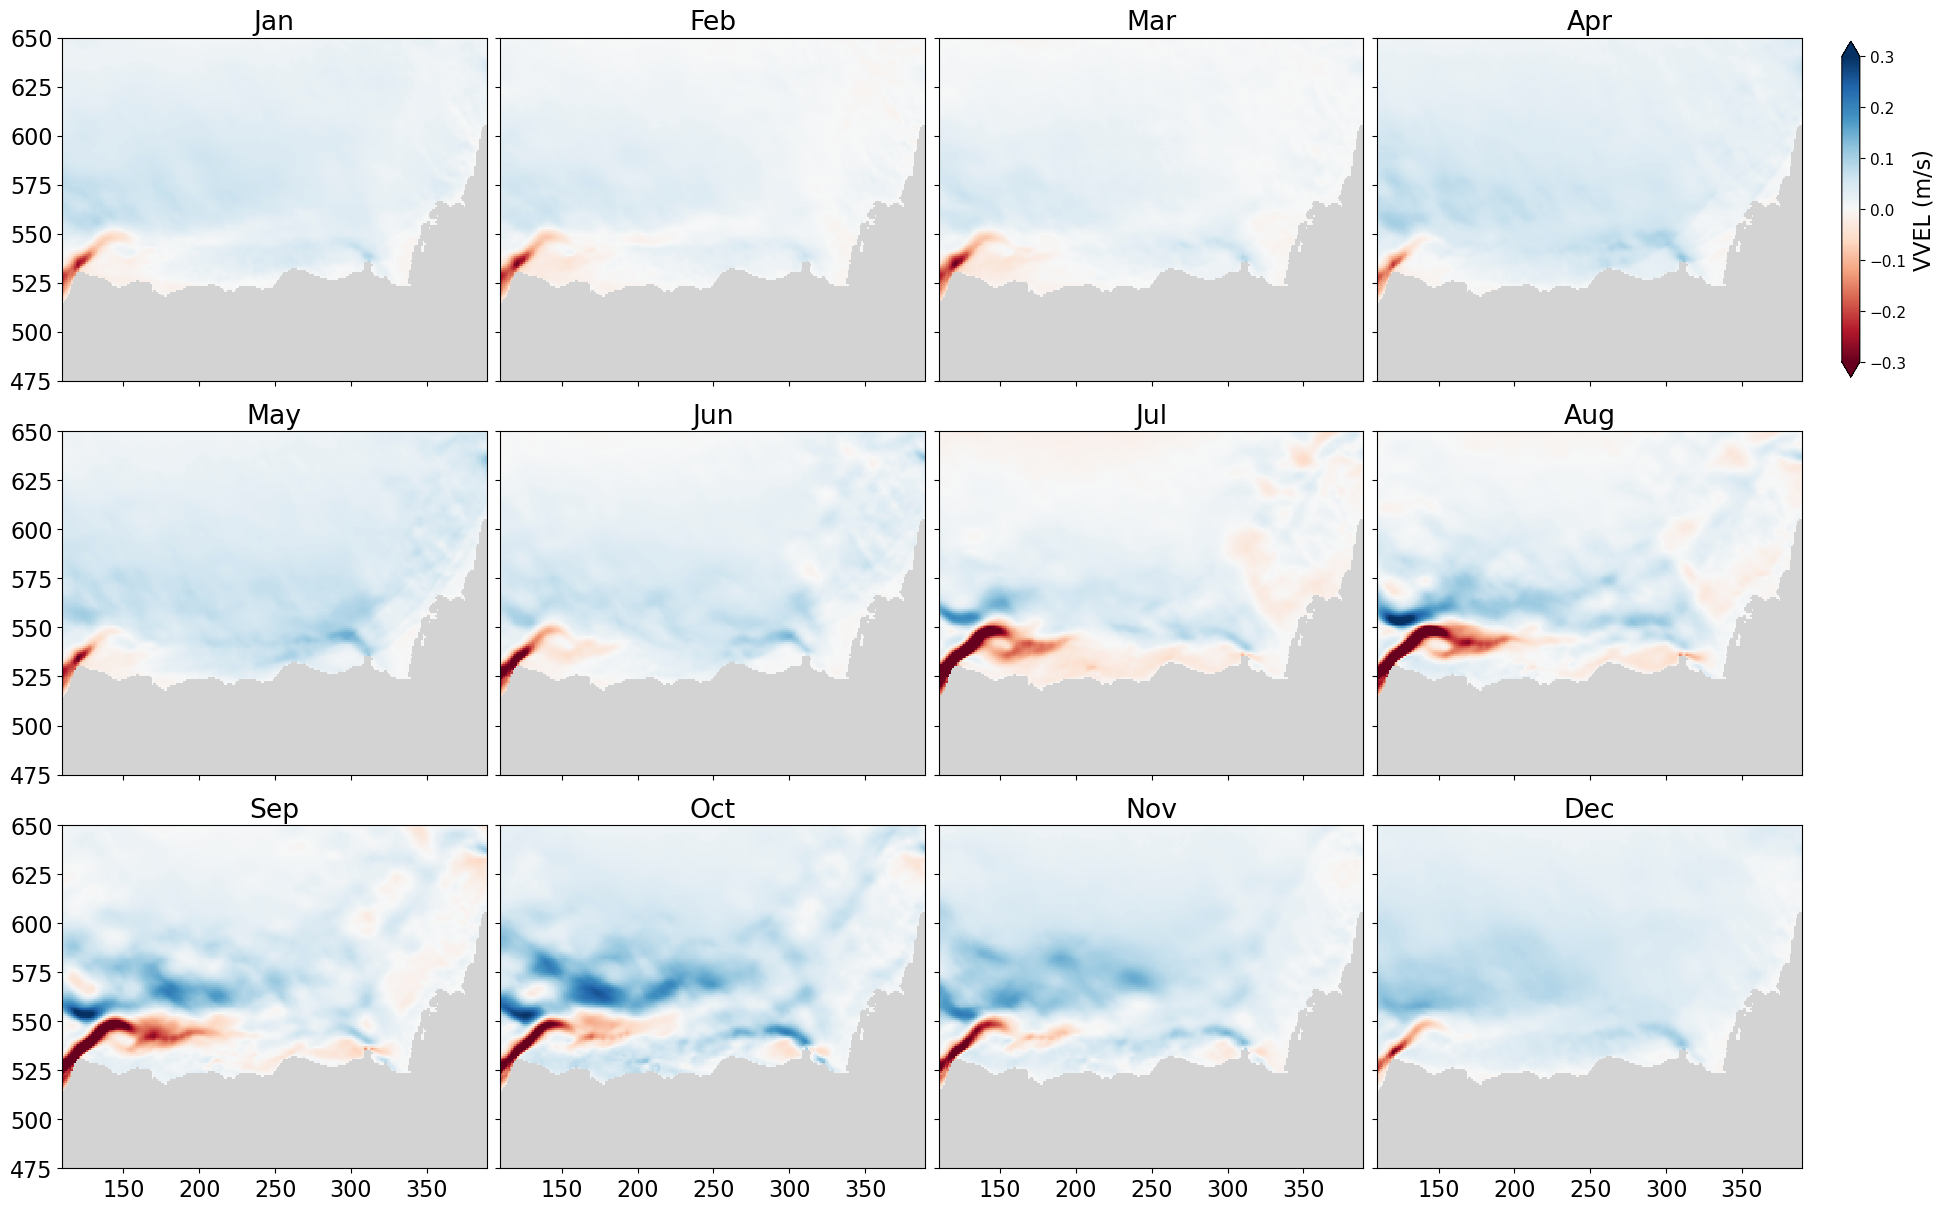

In [96]:
plt.rcParams["font.size"] = 16
fig, axs = plt.subplots(3, 4, figsize=(18, 12), sharex=True, sharey=True, layout='constrained')
axs = axs.ravel()

for i in range(12):
    ax = axs[i]

    # Make background gray
    ax.set_facecolor('lightgray')
    
    # Plot uvel_monthly_mean
    cbar_plot = vvel_monthly_mean_rot.isel(month=i).plot(ax=ax,vmin=-0.3,vmax=0.3,cmap='RdBu',add_colorbar=False,extend='both')

    # ax.set_title(f"Month {i+1}", fontsize=16)
    ax.set_title(f"{['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][i]}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    ax.set_ylim(475,650)

# Add a single colorbar for SSS
cbar_ax = fig.add_axes([1.02, 0.69, 0.01, 0.28])  # left, bottom, width, height
cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical',extend='both')
cbar.set_label("VVEL (m/s)")
cbar.ax.tick_params(labelsize=11)

In [112]:
# Group by month and compute climatological monthly means
uvel_monthly_mean_tmp = uvel_beaufort_rot.groupby('time.month').mean('time')
vvel_monthly_mean_tmp = vvel_beaufort_rot.groupby('time.month').mean('time')

In [113]:
# Need to multiply j by -1 because we are rotating and the vector sign will change
# Also, with the rotation, the i's (x) become j's (y) and the j's (y) become i's (x)
vvel_monthly_mean_rot = uvel_monthly_mean_tmp
uvel_monthly_mean_rot = vvel_monthly_mean_tmp*-1

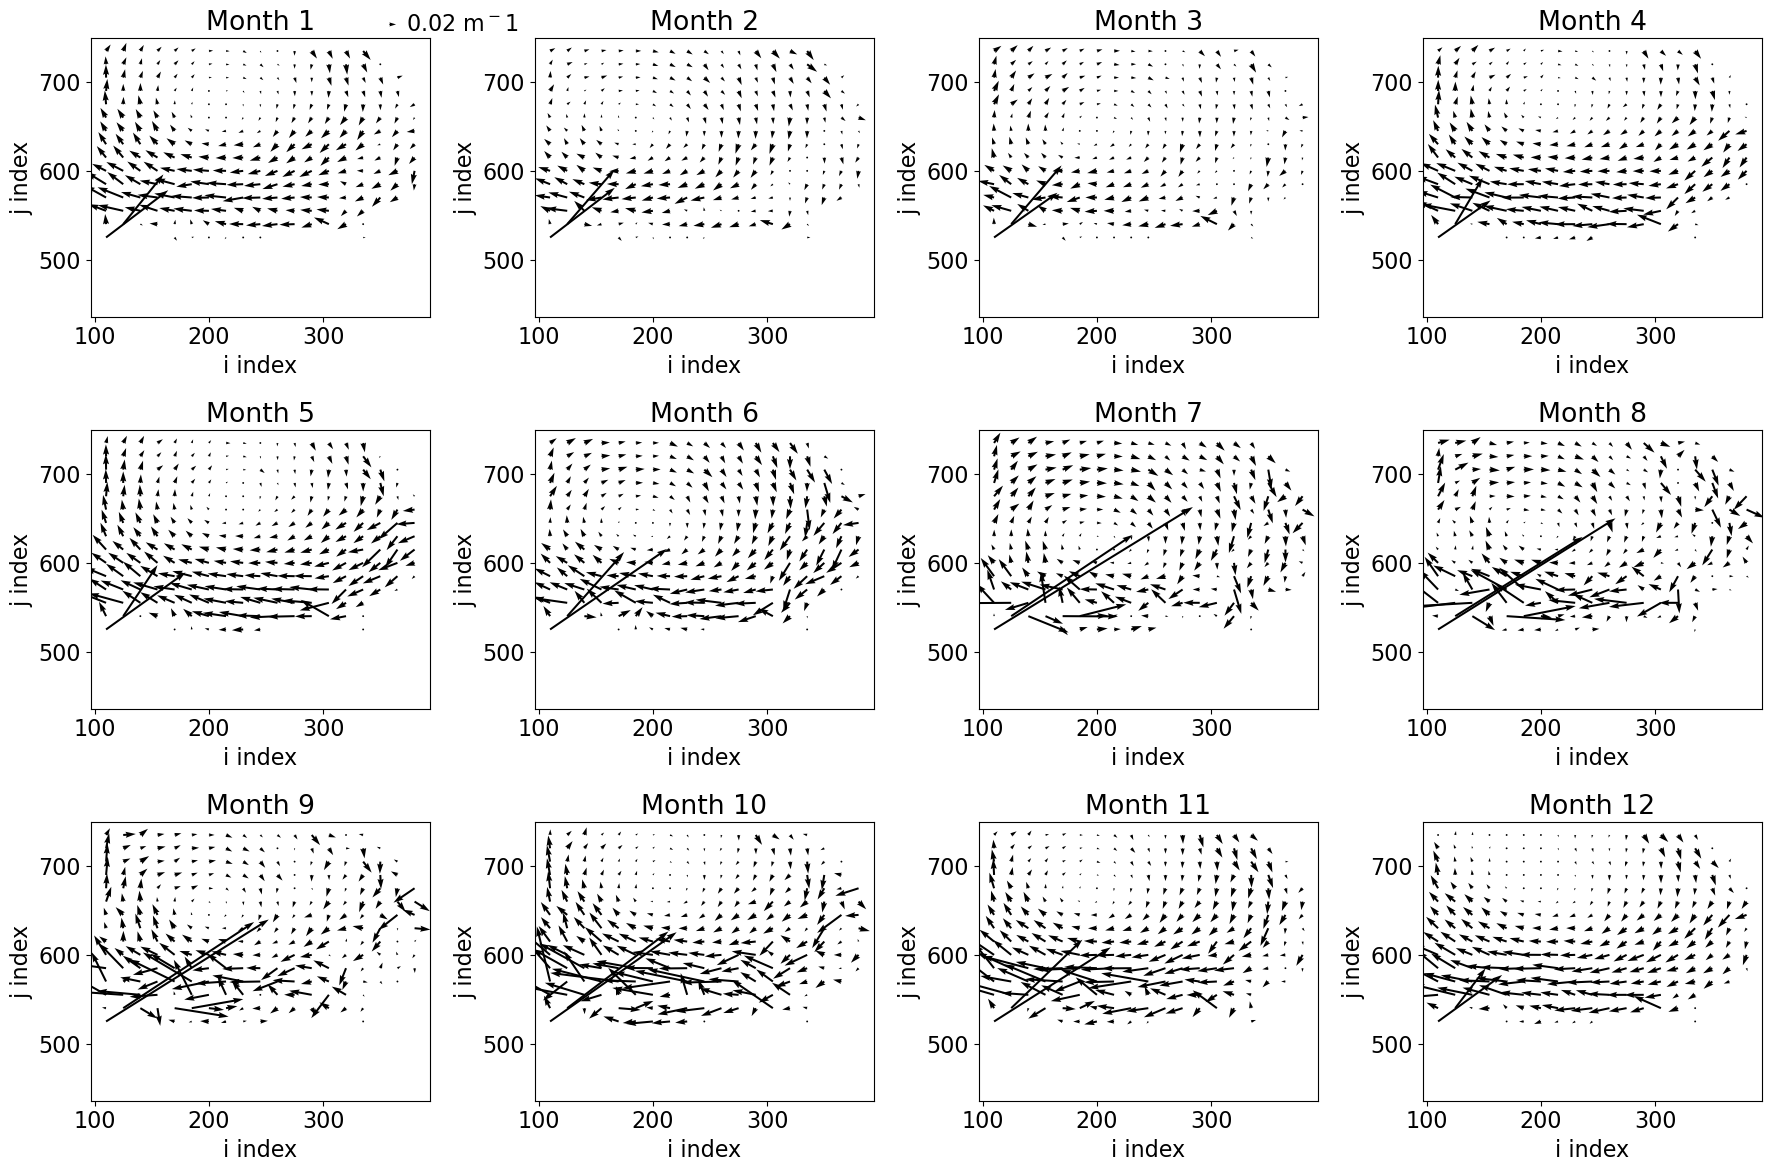

In [99]:
# Subsampling to reduce clutter in quiver plot
step = 15
ii = uvel_monthly_mean_rot['i'][::step]
jj = uvel_monthly_mean_rot['j'][::step]

fig, axs = plt.subplots(3, 4, figsize=(18, 12))
axs = axs.ravel()

# Compute max vector magnitude across all months for consistent scaling
max_magnitude = 0
for i in range(12):
    uvel_sel = uvel_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    vvel_sel = vvel_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    mag = np.sqrt(uvel_sel.values**2 + vvel_sel.values**2)
    max_magnitude = max(max_magnitude, np.nanmax(mag))

# Define a consistent quiver scale
scale = 0.3

for i in range(12):
    ax = axs[i]
    
    # Select the month (months indexed 0 to 11)
    uvel_sel = uvel_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    vvel_sel = vvel_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    
    # Meshgrid of i and j for quiver input
    j_grid, i_grid = np.meshgrid(jj, ii)
    
    # Use .values to extract data for quiver
    Q = ax.quiver(j_grid, i_grid,
                  uvel_sel.values, vvel_sel.values,
                  scale=scale, angles='uv', scale_units='inches',width=0.006)
    
    ax.set_title(f"Month {i+1}")
    ax.set_xlabel("i index")
    ax.set_ylabel("j index")

    # Add a quiver key to one of the plots (say, first subplot)
    if i == 0:
        ax.quiverkey(Q, 0.9, 1.05, 0.02, '0.02 m${^-1}$',
                     labelpos='E', coordinates='axes')

plt.tight_layout()
plt.show()

In [114]:
# Group by month and compute climatological monthly means
uvel_monthly_mean = uvel_beaufort.groupby('time.month').mean('time')
vvel_monthly_mean = vvel_beaufort.groupby('time.month').mean('time')

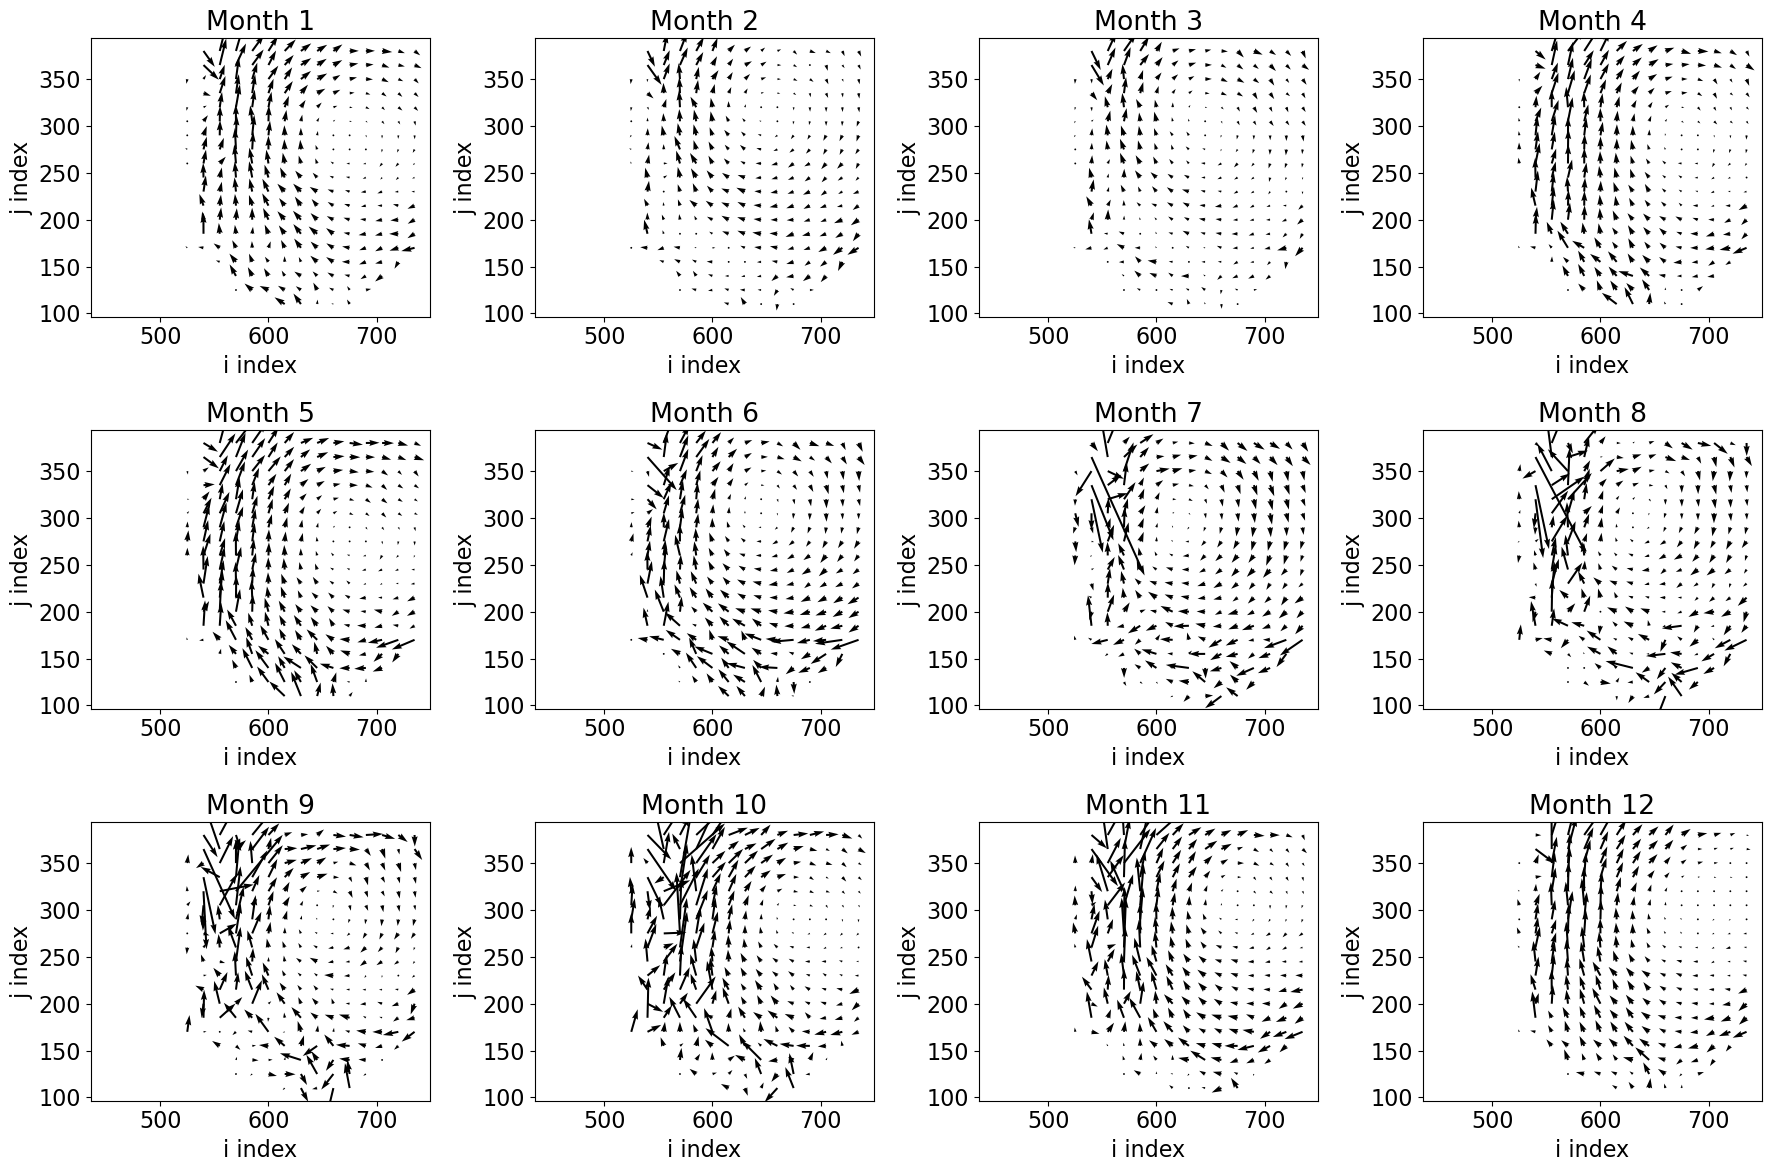

In [74]:
# Subsampling to reduce clutter in quiver plot
step = 15
ii = uvel_monthly_mean['i'][::step]
jj = uvel_monthly_mean['j'][::step]

fig, axs = plt.subplots(3, 4, figsize=(18, 12))
axs = axs.ravel()

# Define a consistent quiver scale
scale = 0.3

for i in range(12):
    ax = axs[i]
    
    # Select the month (months indexed 0 to 11)
    uvel_sel = uvel_monthly_mean.isel(month=i).sel(i=ii, j=jj)
    vvel_sel = vvel_monthly_mean.isel(month=i).sel(i=ii, j=jj)
    
    # Meshgrid of i and j for quiver input
    i_grid, j_grid = np.meshgrid(ii, jj)
    
    # Use .values to extract data for quiver
    ax.quiver(i_grid, j_grid, uvel_sel.values, vvel_sel.values,scale=scale, angles='uv', scale_units='inches',width=0.006)
    
    ax.set_title(f"Month {i+1}")
    ax.set_xlabel("i index")
    ax.set_ylabel("j index")

plt.tight_layout()
plt.show()

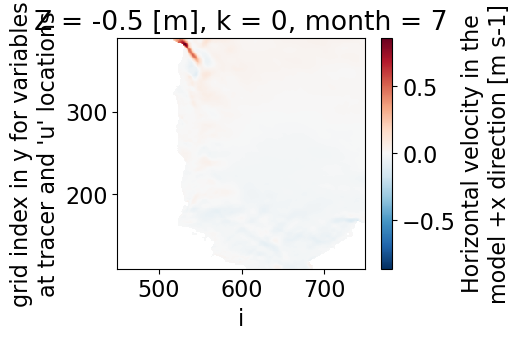

In [115]:
uvel_monthly_mean.sel(month=7).plot(figsize=[4,3]);

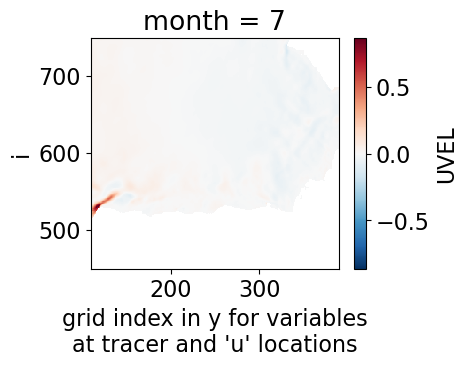

In [117]:
vvel_monthly_mean_rot.sel(month=7).plot(figsize=[4,3]);

### Plot every month with SSS below and a contour for SI=15%

In [31]:
# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

In [32]:
# pull out SSS and SIC for beaufort region
sss_beaufort = salt_da.isel(k=0,i=slice(450,750),j=slice(110,390)).sel(time=slice('2014','2020'))
sic_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390)).sel(time=slice('2014','2020'))

In [33]:
# Rotate the fields so that alaska is on the bottom
sss_beaufort_rot = rotate_dataarray_90ccw(sss_beaufort)
sic_beaufort_rot = rotate_dataarray_90ccw(sic_beaufort)

In [34]:
# Group by month and compute climatological monthly means
sss_monthly_mean_rot = sss_beaufort_rot.groupby('time.month').mean('time')
sic_monthly_mean_rot = sic_beaufort_rot.groupby('time.month').mean('time')

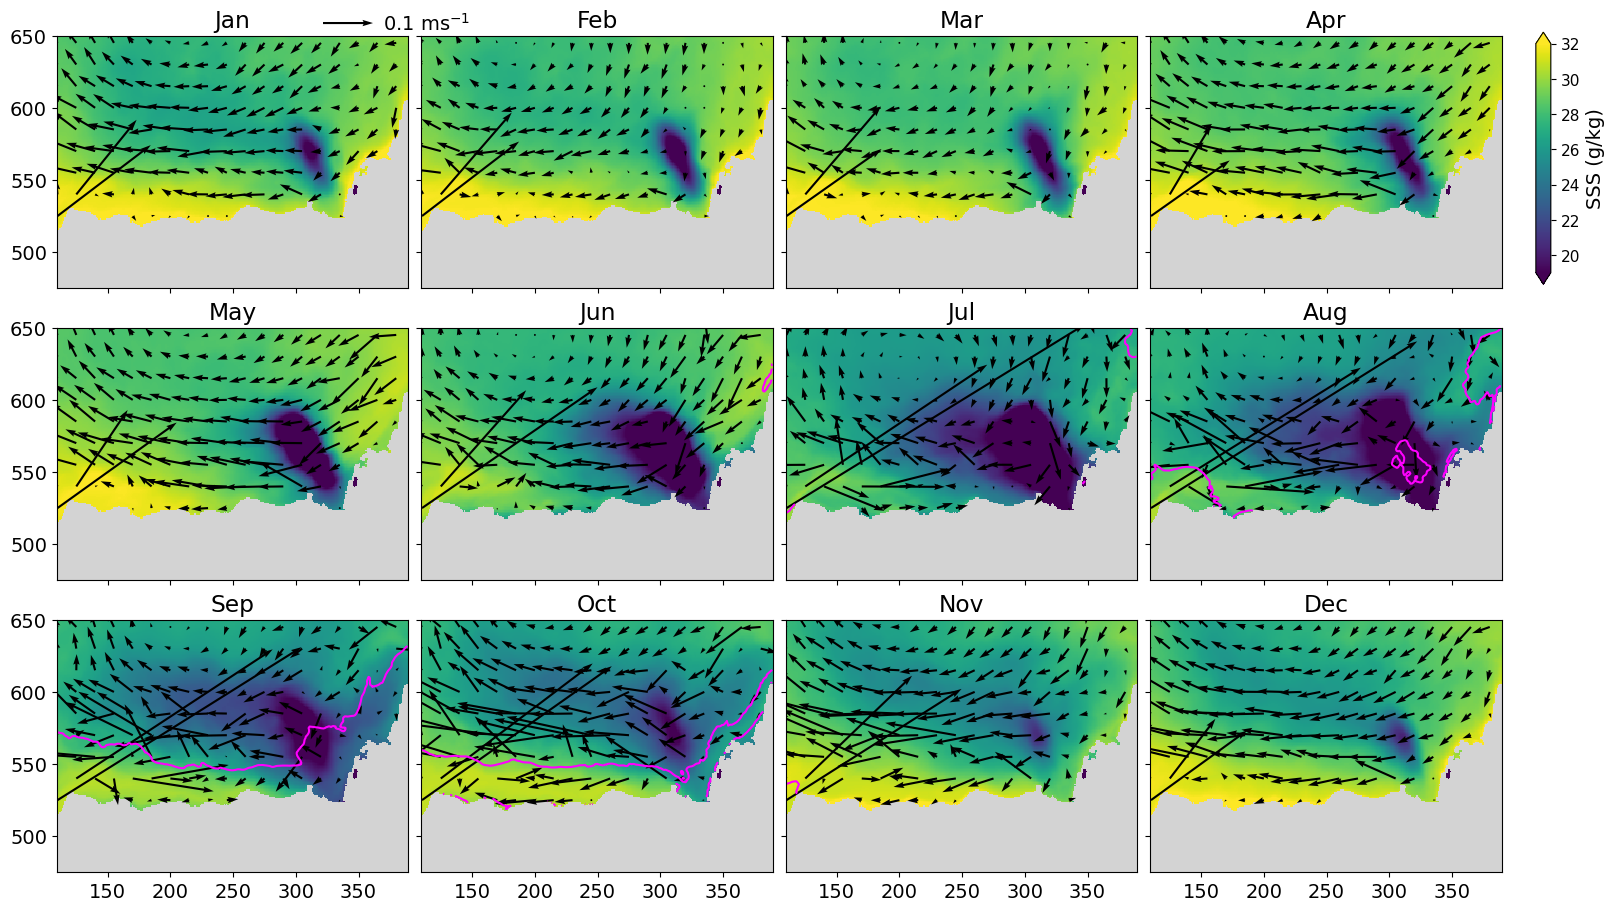

In [200]:
# Subsampling to reduce clutter in quiver plot
plt.rcParams["font.size"] = 14

step = 15
ii = uvel_monthly_mean_rot['i'][::step]
jj = uvel_monthly_mean_rot['j'][::step]

fig, axs = plt.subplots(3, 4, figsize=(15, 9), sharex=True, sharey=True, layout='constrained')
axs = axs.ravel()

# Compute max vector magnitude across all months for consistent scaling
max_magnitude = 0
for i in range(12):
    uvel_sel = uvel_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    vvel_sel = vvel_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    mag = np.sqrt(uvel_sel.values**2 + vvel_sel.values**2)
    max_magnitude = max(max_magnitude, np.nanmax(mag))

# Define a consistent quiver scale
scale = 0.2

for i in range(12):
    ax = axs[i]

    # Make background gray
    ax.set_facecolor('lightgray')
    
    # Plot SSS for each month
    cbar_plot = sss_monthly_mean_rot.isel(month=i).plot(ax=ax,vmin=19,vmax=32,cmap='viridis',add_colorbar=False,extend='both')
    # sic_monthly_mean_rot.isel(month=i).plot(ax=ax,vmin=0,vmax=100,cmap='Blues_r',add_colorbar=False)
    
    # Plot SIC contour at 15% for each month
    sic_monthly_mean_rot.isel(month=i).plot.contour(ax=ax,levels=[15],linewidths=1.5,colors='magenta')
    
    # Select the month (months indexed 0 to 11)
    uvel_sel = uvel_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    vvel_sel = vvel_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    
    # Meshgrid of i and j for quiver input
    j_grid, i_grid = np.meshgrid(jj, ii)
    
    # Use .values to extract data for quiver
    Q = ax.quiver(j_grid, i_grid,
                  uvel_sel.values, vvel_sel.values,
                  scale=scale, angles='uv', scale_units='inches',width=0.006)
    
    # ax.set_title(f"Month {i+1}", fontsize=16)
    ax.set_title(f"{['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][i]}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    ax.set_ylim(475,650)
    
    # Add a quiver key to one of the plots (say, first subplot)
    if i == 0:
        ax.quiverkey(Q, 0.9, 1.05, 0.1, '0.1 ms$^{-1}$',
                     labelpos='E', coordinates='axes')

# Add a single colorbar for SSS
cbar_ax = fig.add_axes([1.02, 0.69, 0.01, 0.28])  # left, bottom, width, height
cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical',extend='both')
cbar.set_label("SSS (g/kg)")
cbar.ax.tick_params(labelsize=11)

plt.show()

### Plot each year August-December

In [192]:
def plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,
                    uvel_beaufort_rot, vvel_beaufort_rot,
                    year=2014, step=10, scale=0.1):
    """
    Plots August to December monthly means for a specified year (2014–2020)
    from daily data arrays.

    Parameters:
    - sss_beaufort_rot, sic_beaufort_rot, uvel_beaufort_rot, vvel_beaufort_rot: xarray DataArrays with 'time', 'i', 'j' dims
    - year: int (2014 to 2020)
    - step: int, subsampling step for quiver arrows
    - scale: float, quiver scale for quiver plot
    """

    plt.rcParams["font.size"] = 14

    # Subsample grid
    ii = uvel_beaufort_rot['i'][::step]
    jj = uvel_beaufort_rot['j'][::step]

    # Filter data for the selected year
    sss_year = sss_beaufort_rot.sel(time=str(year))
    sic_year = sic_beaufort_rot.sel(time=str(year))
    uvel_year = uvel_beaufort_rot.sel(time=str(year))
    vvel_year = vvel_beaufort_rot.sel(time=str(year))

    # Compute monthly means
    sss_monthly = sss_year.groupby('time.month').mean('time')
    sic_monthly = sic_year.groupby('time.month').mean('time')
    uvel_monthly_tmp = uvel_year.groupby('time.month').mean('time')
    vvel_monthly_tmp = vvel_year.groupby('time.month').mean('time')

    # Need to multiply j by -1 because we are rotating and the vector sign will change
    # Also, with the rotation, the i's (x) become j's (y) and the j's (y) become i's (x)
    vvel_monthly = uvel_monthly_tmp
    uvel_monthly = vvel_monthly_tmp*-1

    # Set up subplots for August–December (months 8–12)
    fig, axs = plt.subplots(1, 5, figsize=(20, 3.5), sharex=True, sharey=True, layout='constrained')

    # Consistent quiver scale based on max magnitude
    max_magnitude = 0
    for m in range(8, 13):
        uvel_sel = uvel_monthly.sel(month=m).sel(i=ii, j=jj)
        vvel_sel = vvel_monthly.sel(month=m).sel(i=ii, j=jj)
        mag = np.sqrt(uvel_sel**2 + vvel_sel**2)
        max_magnitude = max(max_magnitude, np.nanmax(mag))

    for plot_i, month_i in enumerate(range(8, 13)):
        ax = axs[plot_i]
        ax.set_facecolor('lightgray')

        # Plot SSS
        cbar_plot = sss_monthly.sel(month=month_i).plot(ax=ax, vmin=19, vmax=32, cmap='viridis', add_colorbar=False)

        # Plot SIC 15% contour
        sic_monthly.sel(month=month_i).plot.contour(ax=ax, levels=[15], linewidths=1.5, colors='magenta')

        # Quiver arrows
        uvel_sel = uvel_monthly.sel(month=month_i).sel(i=ii, j=jj)
        vvel_sel = vvel_monthly.sel(month=month_i).sel(i=ii, j=jj)
        j_grid, i_grid = np.meshgrid(jj, ii)

        Q = ax.quiver(j_grid, i_grid,
                      uvel_sel.values, vvel_sel.values,
                      scale=scale, angles='uv', scale_units='inches', width=0.004)

        if plot_i == 0:
            ax.quiverkey(Q, 0.9, 1.05, 0.2, '0.2 ms$^{-1}$',
                         labelpos='E', coordinates='axes')

        ax.set_title(f"{['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][month_i-1]}", fontsize=20)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_ylim(475,650)
        
    fig.text(0.01,1.01,year, fontsize=22)

    # Add a single colorbar for SSS
    cbar_ax = fig.add_axes([1.01, 0.09, 0.01, 0.8])  # left, bottom, width, height
    cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical',extend='both')
    cbar.set_label("SSS (g/kg)")
    cbar.ax.tick_params(labelsize=11)
    
    plt.show()

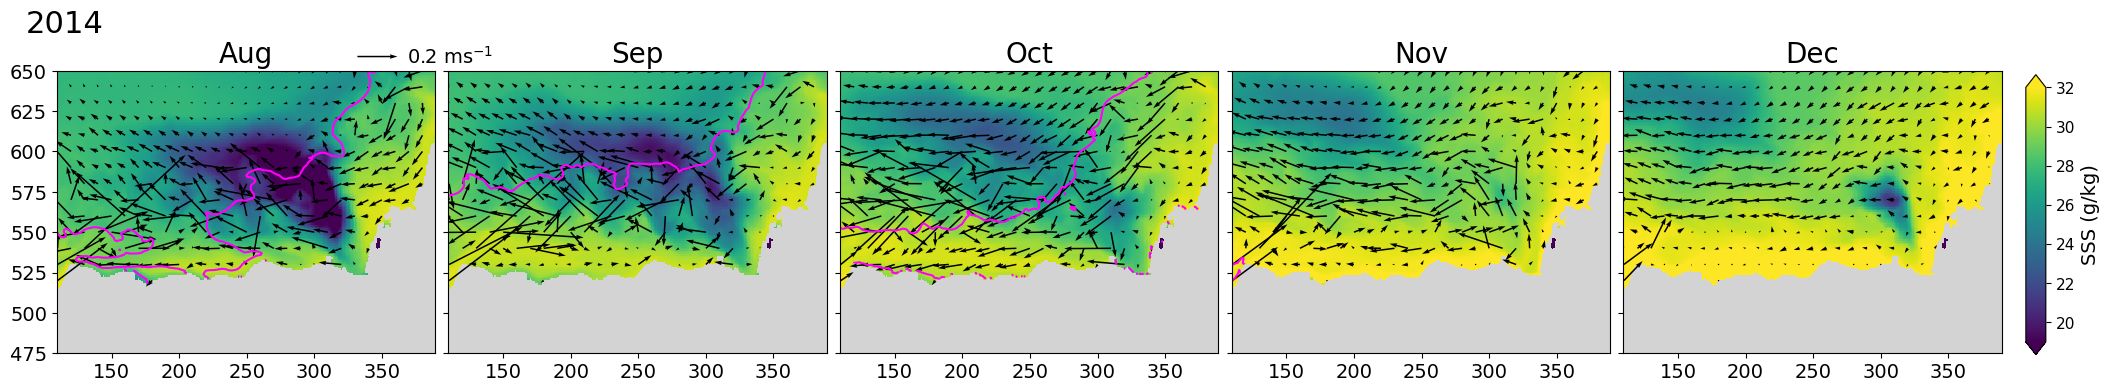

In [193]:
# 2014
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,uvel_beaufort_rot, vvel_beaufort_rot,year=2014,scale=0.5)

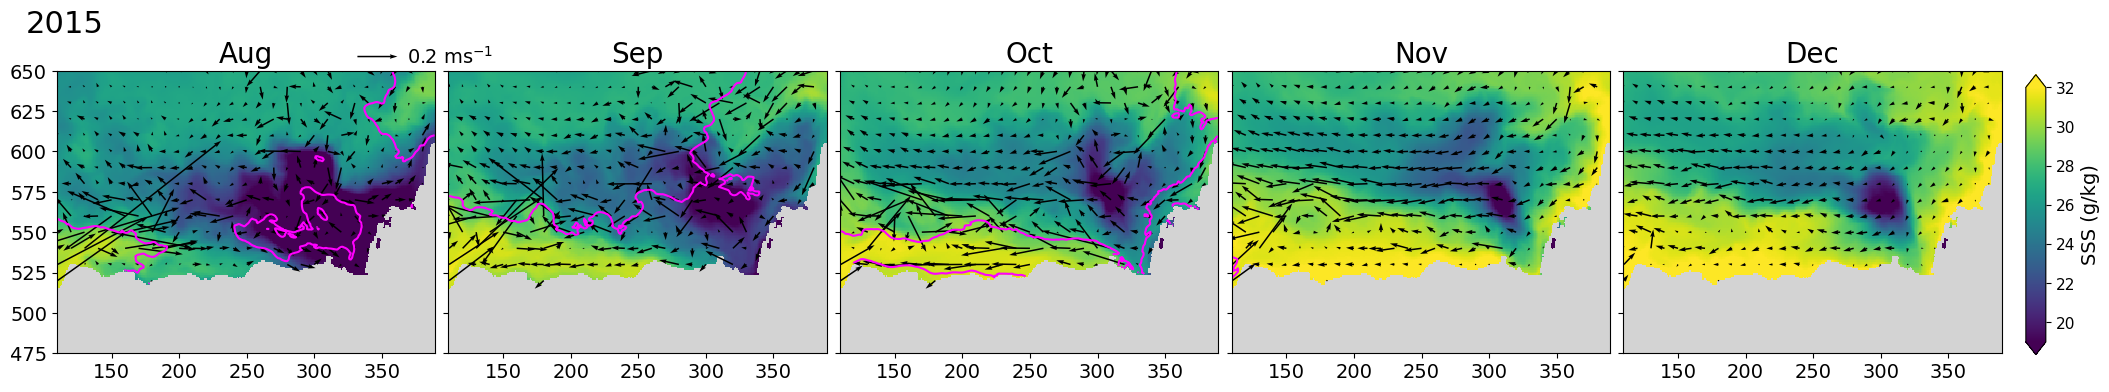

In [194]:
# 2015
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,uvel_beaufort_rot, vvel_beaufort_rot,year=2015,scale=0.5)

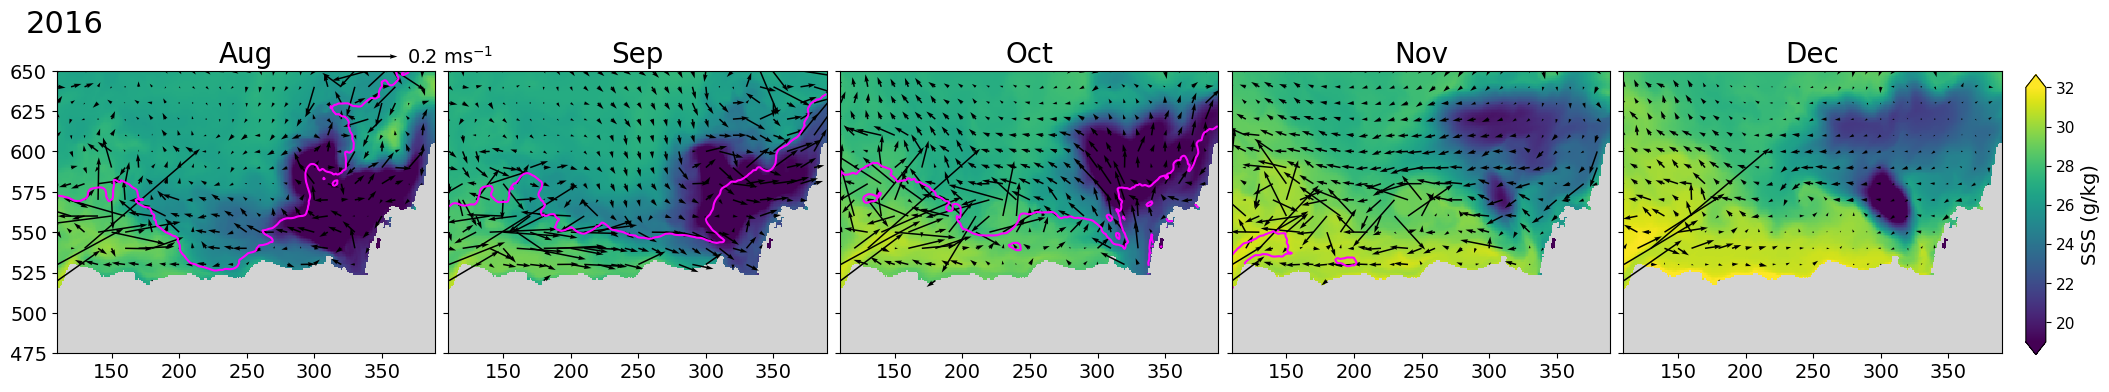

In [195]:
# 2016
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,uvel_beaufort_rot, vvel_beaufort_rot,year=2016,scale=0.5)

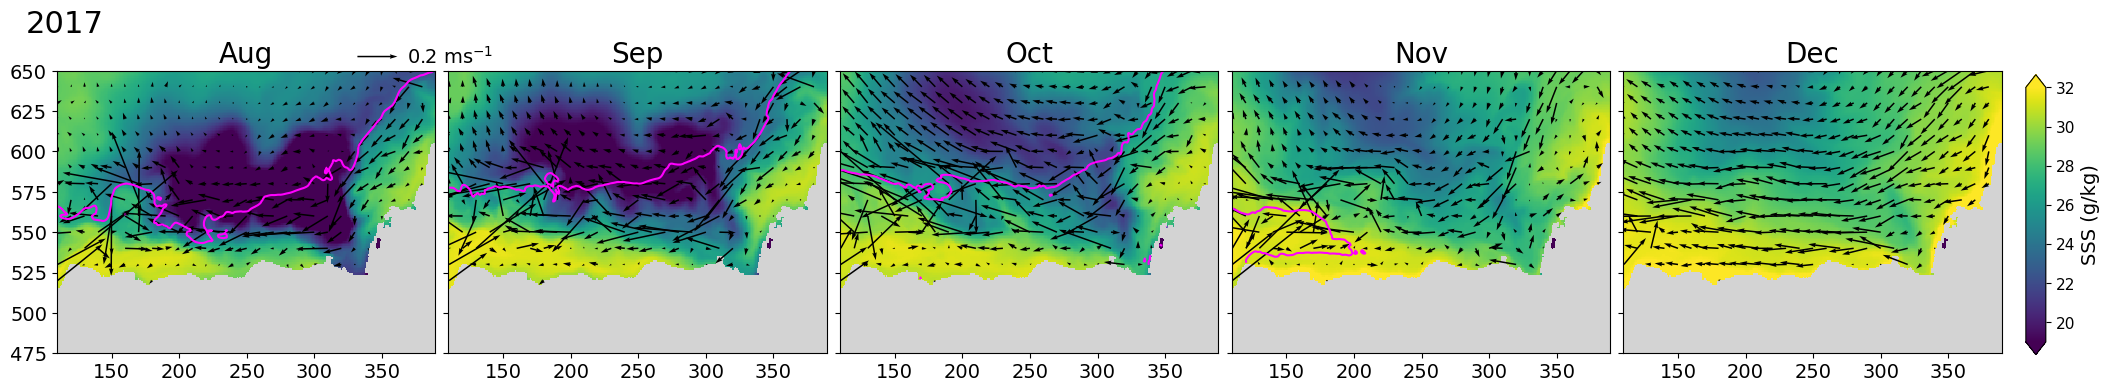

In [196]:
# 2017
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,uvel_beaufort_rot, vvel_beaufort_rot,year=2017,scale=0.5)

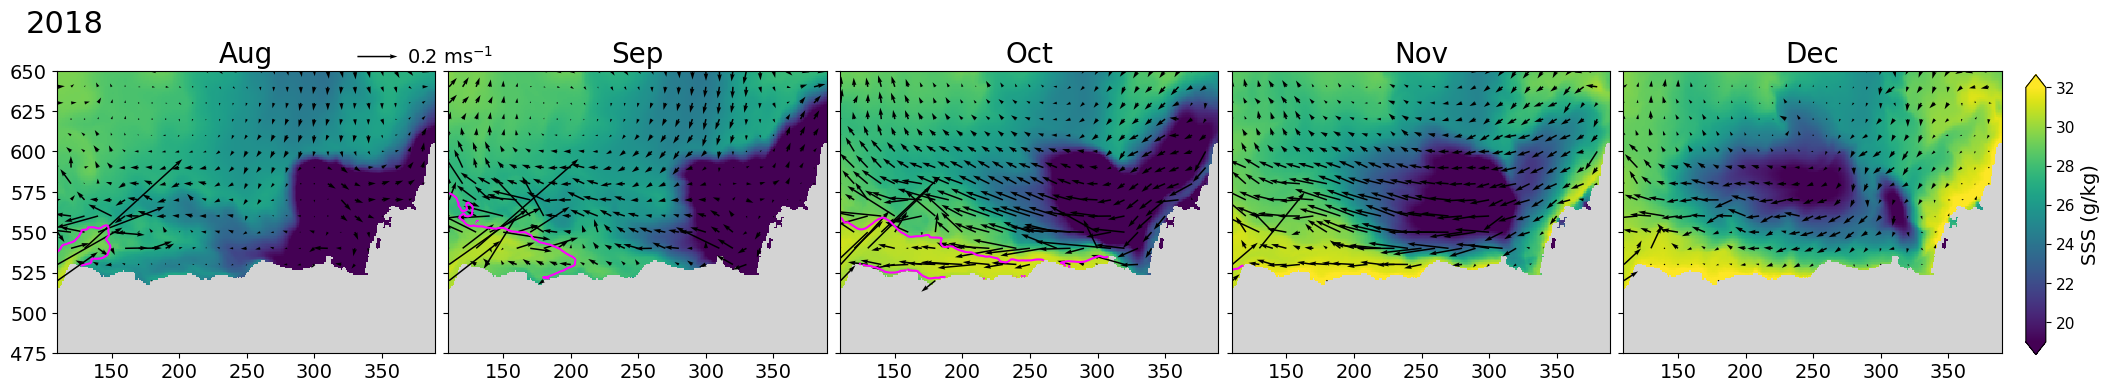

In [197]:
# 2018
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,uvel_beaufort_rot, vvel_beaufort_rot,year=2018,scale=0.5)

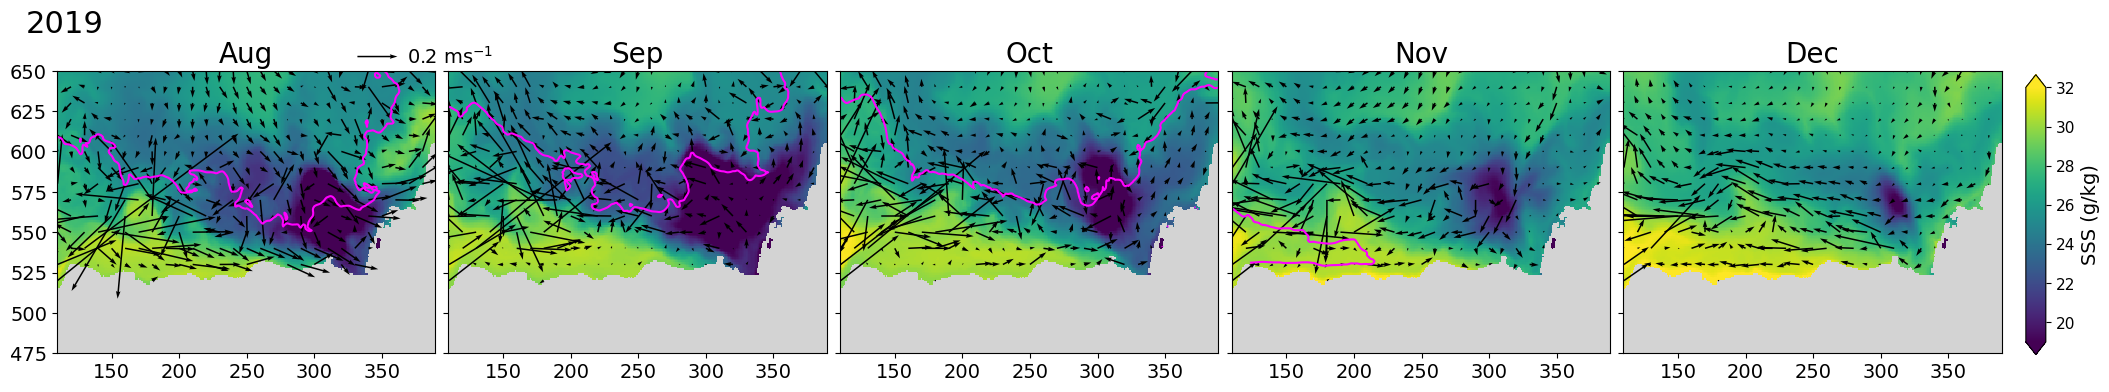

In [198]:
# 2019
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,uvel_beaufort_rot, vvel_beaufort_rot,year=2019,scale=0.5)

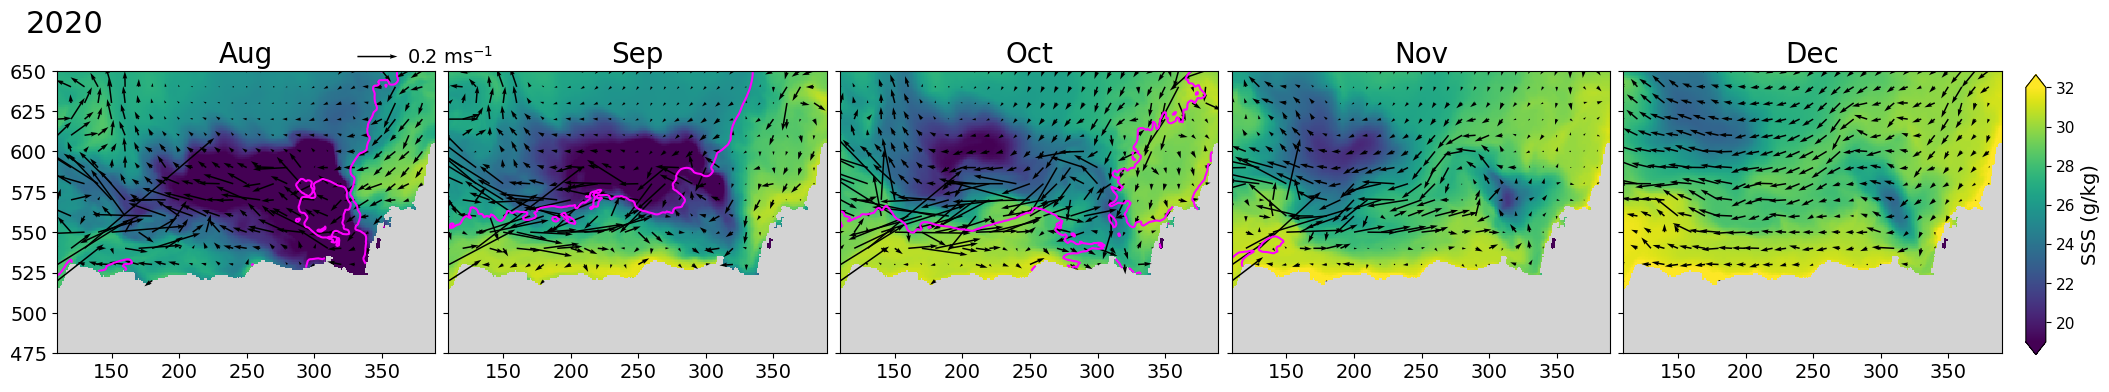

In [199]:
# 2020
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,uvel_beaufort_rot, vvel_beaufort_rot,year=2020,scale=0.5)